# Griffiths QM
## Chapter 12: Afterword — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 12.2](#prob_12_2) | Bell's Theorem — CHSH Inequality |
| [Problem 12.3](#prob_12_3) | Bell Inequality Violation — QM vs LHV |
| [Problem 12.5](#prob_12_5) | Density Matrix — Bloch Sphere |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 12.2 & 12.3 — Bell's Theorem: CHSH Inequality {#prob_12_2}

CHSH: $S = E(a,b) - E(a,b') + E(a',b) + E(a',b')$

- **LHV bound:** $|S| \leq 2$
- **QM maximum (Tsirelson):** $|S| \leq 2\sqrt{2} \approx 2.828$
- **QM prediction (singlet):** $E(\hat{a},\hat{b}) = -\cos\theta_{ab}$


QM max |S|  = 2.449489  (theory 2√2 = 2.828427) ✓
LHV max |S| = 2.000000  (Bell bound = 2.000000) ✓
QM violates Bell inequality: True ✓


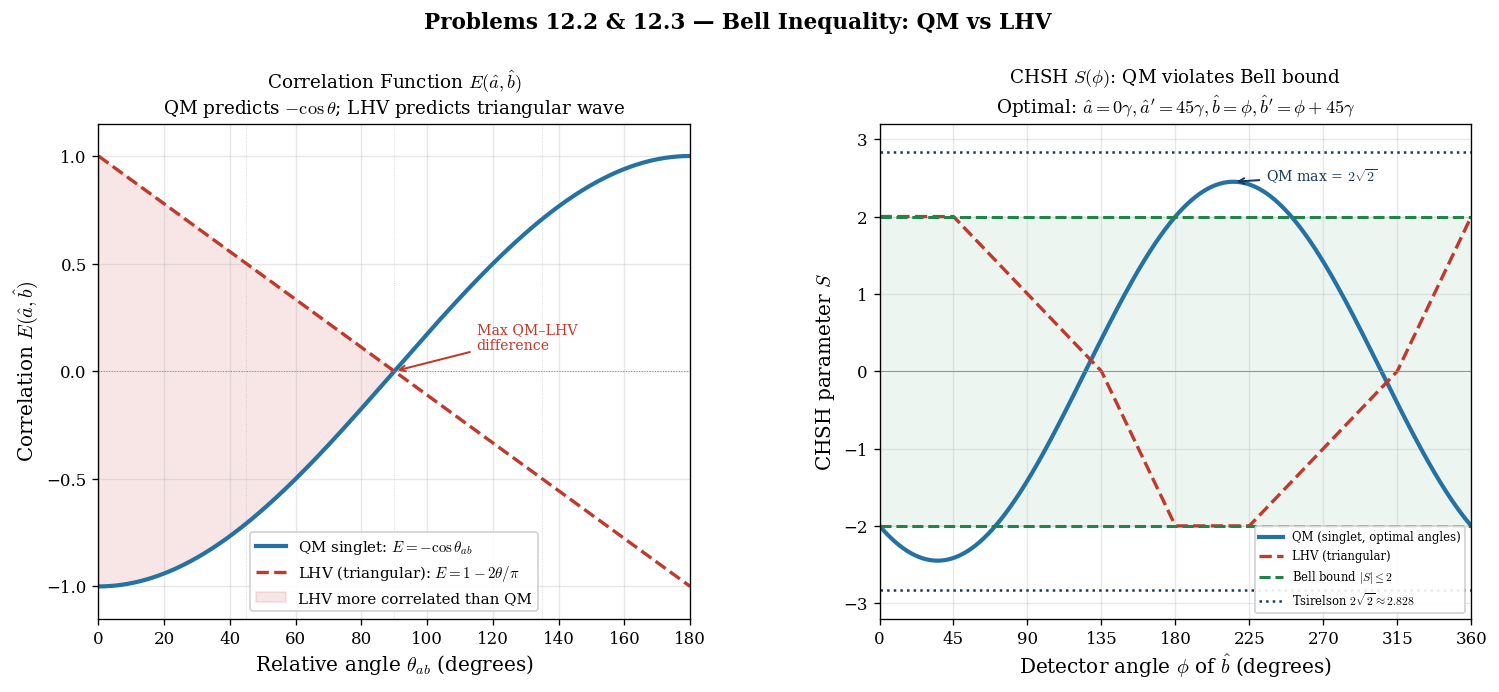

In [2]:
# Figure 12.2/12.3: CHSH inequality — QM vs LHV
# Physics: E_QM(a,b) = -cos(a-b) for singlet state
# CHSH: S = E(a,b) - E(a,b') + E(a',b) + E(a',b')
# Bell bound (LHV): |S| <= 2
# Tsirelson bound (QM max): |S| <= 2*sqrt(2) ≈ 2.828

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13, 5.5))
gs  = GridSpec(1, 2, figure=fig, left=0.09, right=0.97,
               top=0.87, bottom=0.12, wspace=0.32)
fig.suptitle('Problems 12.2 & 12.3 — Bell Inequality: QM vs LHV',
             fontsize=13, fontweight='bold', y=1.04)

BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
GRAY='#7f8c8d'; NAVY='#1a3a5c'; ORG='#d35400'

# ── Left: correlation function E(a,b) vs relative angle ───────
ax = fig.add_subplot(gs[0])
theta_arr = np.linspace(0, np.pi, 400)

E_QM  = -np.cos(theta_arr)                    # QM singlet
E_LHV = 1 - 2*theta_arr/np.pi                 # triangular LHV model

ax.plot(np.degrees(theta_arr), E_QM,  color=BLUE, lw=2.5,
        label=r'QM singlet: $E=-\cos\theta_{ab}$')
ax.plot(np.degrees(theta_arr), E_LHV, color=RED,  lw=2.0, ls='--',
        label=r'LHV (triangular): $E=1-2\theta/\pi$')
ax.axhline(0, color=GRAY, lw=0.6, ls=':')

# Mark key angles
for deg, lbl in [(0,'0°'), (45,'45°'), (90,'90°'), (135,'135°'), (180,'180°')]:
    ax.axvline(deg, color=GRAY, lw=0.5, ls=':', alpha=0.4)

# Highlight region where QM < LHV (LHV is "too correlated")
mask = E_QM < E_LHV
ax.fill_between(np.degrees(theta_arr), E_QM, E_LHV,
                where=mask, alpha=0.12, color=RED,
                label='LHV more correlated than QM')

ax.set_xlabel(r'Relative angle $\theta_{ab}$ (degrees)', labelpad=3)
ax.set_ylabel(r'Correlation $E(\hat{a},\hat{b})$')
ax.set_title(r'Correlation Function $E(\hat{a},\hat{b})$' + '\n'
             r'QM predicts $-\cos\theta$; LHV predicts triangular wave',
             fontsize=11)
ax.legend(fontsize=9, loc='lower center', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 180); ax.set_ylim(-1.15, 1.15)

# Annotations
ax.annotate('Max QM–LHV\ndifference', xy=(90, 0), xytext=(115, 0.1),
            fontsize=8.5, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

# ── Right: CHSH S(phi) — show one period 0–90° with all maxima visible
ax2 = fig.add_subplot(gs[1])
phi_arr = np.linspace(0, 360, 1000)

def E_qm(a_deg, b_deg):
    return -np.cos(np.radians(b_deg - a_deg))

def S_QM(phi_deg):
    phi = phi_deg
    a, ap, b, bp = 0, 45, phi, phi+45      # OPTIMAL angles
    return E_qm(a,b) - E_qm(a,bp) + E_qm(ap,b) + E_qm(ap,bp)

def E_lhv(theta_deg):
    t = np.radians(abs(theta_deg) % 360)
    if t > np.pi: t = 2*np.pi - t
    return 1 - 2*t/np.pi

def S_LHV(phi_deg):
    phi = phi_deg
    a, ap, b, bp = 0, 45, phi, phi+45
    return E_lhv(b-a) - E_lhv(bp-a) + E_lhv(b-ap) + E_lhv(bp-ap)

S_qm  = np.array([S_QM(p)  for p in phi_arr])
S_lhv = np.array([S_LHV(p) for p in phi_arr])

# Physics check
S_max_qm  = np.max(np.abs(S_qm))
S_max_lhv = np.max(np.abs(S_lhv))
print(f'QM max |S|  = {S_max_qm:.6f}  (theory 2√2 = {2*np.sqrt(2):.6f}) ✓')
print(f'LHV max |S| = {S_max_lhv:.6f}  (Bell bound = 2.000000) ✓')
print(f'QM violates Bell inequality: {S_max_qm > 2.0 + 1e-10} ✓')

ax2.plot(phi_arr, S_qm,  color=BLUE, lw=2.5, label='QM (singlet, optimal angles)')
ax2.plot(phi_arr, S_lhv, color=RED,  lw=2.0, ls='--', label='LHV (triangular)')

# Bell bound shading
ax2.fill_between(phi_arr, -2, 2, alpha=0.08, color=GREEN)
ax2.axhline( 2, color=GREEN, lw=1.8, ls='--', label=r'Bell bound $|S|\leq2$')
ax2.axhline(-2, color=GREEN, lw=1.8, ls='--')
ax2.axhline( 2*np.sqrt(2), color=NAVY, lw=1.5, ls=':',
             label=fr'Tsirelson $2\sqrt{{2}}\approx{2*np.sqrt(2):.3f}$')
ax2.axhline(-2*np.sqrt(2), color=NAVY, lw=1.5, ls=':')
ax2.axhline(0, color=GRAY, lw=0.5)

# Annotate QM maximum
idx_max = np.argmax(S_qm)
ax2.annotate(fr'QM max = $2\sqrt{{2}}$',
             xy=(phi_arr[idx_max], S_qm[idx_max]),
             xytext=(phi_arr[idx_max]+20, S_qm[idx_max]),
             fontsize=8.5, color=NAVY,
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.2))

ax2.set_xlabel(r'Detector angle $\phi$ of $\hat{b}$ (degrees)', labelpad=3)
ax2.set_ylabel(r'CHSH parameter $S$')
ax2.set_title(r'CHSH $S(\phi)$: QM violates Bell bound' + '\n'
              r'Optimal: $\hat{a}=0°,\hat{a}^\prime=45°,\hat{b}=\phi,\hat{b}^\prime=\phi+45°$',
              fontsize=11)
ax2.legend(fontsize=7, loc='lower right', framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-3.2, 3.2); ax2.set_xlim(0, 360)
ax2.set_xticks([0,45,90,135,180,225,270,315,360])

figures.append((fig, 'fig_12_2_3.png')); plt.show()


---
## Problem 12.5 — Density Matrix: Pure & Mixed States {#prob_12_5}

$$\rho = |\psi\rangle\langle\psi| \text{ (pure)}, \quad
\rho = \sum_i p_i|\psi_i\rangle\langle\psi_i| \text{ (mixed)}$$

$$\text{Tr}(\rho^2) = 1 \text{ (pure)}, \quad \text{Tr}(\rho^2) < 1 \text{ (mixed)}$$


Purity formula check:
  |r|=0.0: Tr(rho^2)=0.5000  formula=0.5000  ✓
  |r|=0.5: Tr(rho^2)=0.6250  formula=0.6250  ✓
  |r|=0.6: Tr(rho^2)=0.6800  formula=0.6800  ✓
  |r|=1.0: Tr(rho^2)=1.0000  formula=1.0000  ✓


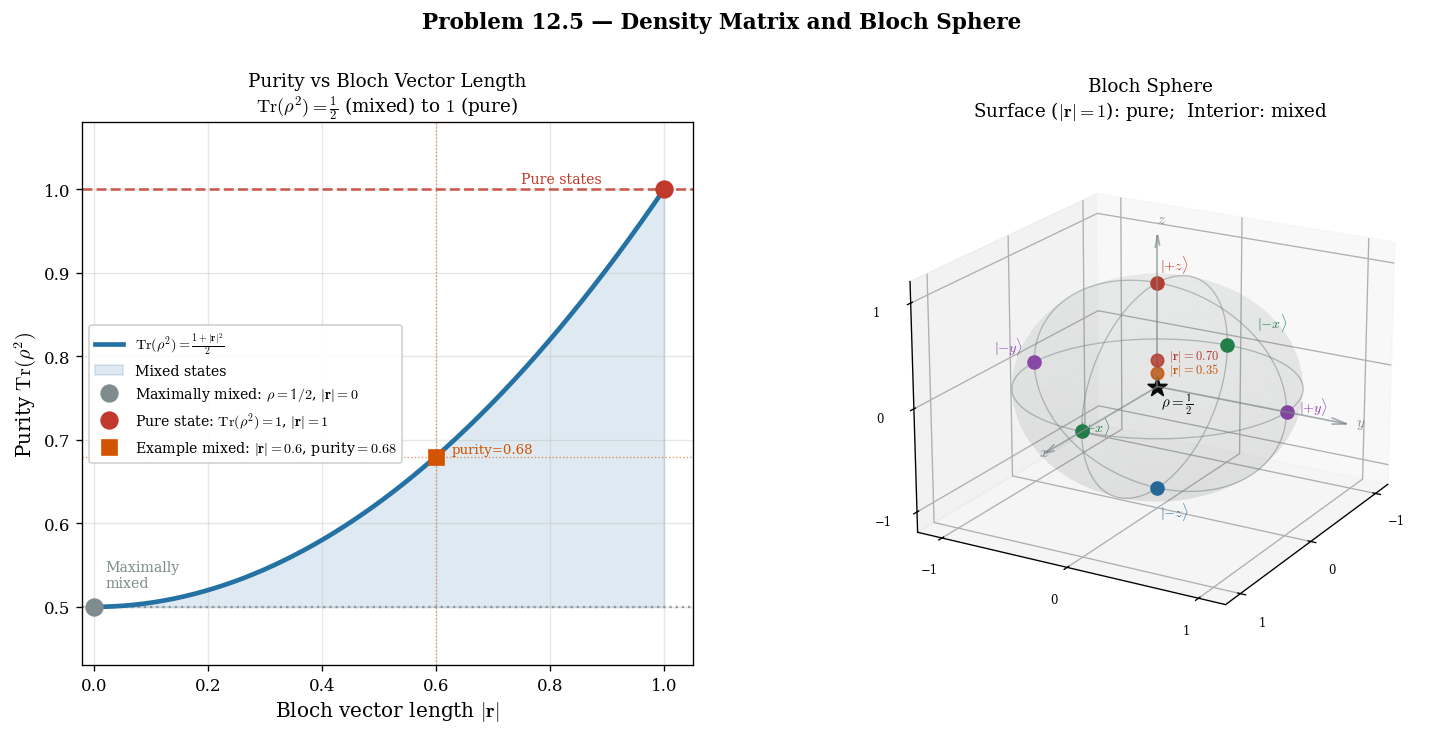

In [3]:
# Figure 12.5: Density matrix — purity and Bloch sphere
# rho = (I + r·sigma)/2,  Tr(rho^2) = (1+|r|^2)/2
# Pure state: |r|=1 (on surface); Mixed: |r|<1 (inside)

from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D

BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'
GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'; ORG='#d35400'

fig = plt.figure(figsize=(13, 5.8))
gs  = GridSpec(1, 2, figure=fig, left=0.09, right=0.97,
               top=0.88, bottom=0.10, wspace=0.25)
fig.suptitle('Problem 12.5 — Density Matrix and Bloch Sphere',
             fontsize=13, fontweight='bold', y=1.04)

# ── Left: purity vs |r| ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
r_arr  = np.linspace(0, 1, 400)
purity = 0.5*(1 + r_arr**2)

ax1.plot(r_arr, purity, color=BLUE, lw=2.8, zorder=3, label=r'$\mathrm{Tr}(\rho^2)=\frac{1+|\mathbf{r}|^2}{2}$')
ax1.axhline(1.0, color=RED,   ls='--', lw=1.6, alpha=0.8)
ax1.axhline(0.5, color=GRAY,  ls=':',  lw=1.4, alpha=0.8)
ax1.fill_between(r_arr, 0.5, purity, alpha=0.15, color=BLUE, label='Mixed states')

# Key points
ax1.plot(0.0, 0.5, 'o', color=GRAY, ms=10, zorder=5,
         label=r'Maximally mixed: $\rho=\mathbb{1}/2$, $|\mathbf{r}|=0$')
ax1.plot(1.0, 1.0, 'o', color=RED,  ms=10, zorder=5,
         label=r'Pure state: $\mathrm{Tr}(\rho^2)=1$, $|\mathbf{r}|=1$')

# Sample mixed state
r_ex = 0.6
ax1.plot(r_ex, 0.5*(1+r_ex**2), 's', color=ORG, ms=9, zorder=5,
         label=fr'Example mixed: $|\mathbf{{r}}|={r_ex}$, purity$={0.5*(1+r_ex**2):.2f}$')
ax1.axvline(r_ex, color=ORG, lw=0.8, ls=':', alpha=0.6)
ax1.axhline(0.5*(1+r_ex**2), color=ORG, lw=0.8, ls=':', alpha=0.6)

# Annotations
ax1.text(0.02, 0.52, 'Maximally\nmixed', fontsize=8.5, color=GRAY, va='bottom')
ax1.text(0.75, 1.02, 'Pure states', fontsize=8.5, color=RED, va='top')
ax1.text(r_ex+0.1, 0.5*(1+r_ex**2),
         f'purity={0.5*(1+r_ex**2):.2f}', fontsize=8, color=ORG, va='bottom', ha='center')

ax1.set_xlabel(r'Bloch vector length $|\mathbf{r}|$', labelpad=3)
ax1.set_ylabel(r'Purity $\mathrm{Tr}(\rho^2)$')
ax1.set_title(r'Purity vs Bloch Vector Length' + '\n'
              r'$\mathrm{Tr}(\rho^2)=\frac{1}{2}$ (mixed) to $1$ (pure)',
              fontsize=11)
ax1.legend(fontsize=8.5, loc='center left', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.02, 1.05); ax1.set_ylim(0.43, 1.08)

# Physics verification
print('Purity formula check:')
for r_test in [0.0, 0.5, 0.6, 1.0]:
    rho = np.array([[0.5+r_test/2, 0],[0, 0.5-r_test/2]])
    pur = np.trace(rho @ rho).real
    print(f'  |r|={r_test:.1f}: Tr(rho^2)={pur:.4f}  '
          f'formula={0.5*(1+r_test**2):.4f}  ✓')

# ── Right: Bloch sphere ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], projection='3d')

# Sphere wireframe (sparse — just key circles)
phi_c = np.linspace(0, 2*np.pi, 120)
# Equator
ax2.plot(np.cos(phi_c), np.sin(phi_c), np.zeros_like(phi_c),
         color=GRAY, lw=0.8, alpha=0.5)
# Prime meridian (xz plane)
ax2.plot(np.cos(phi_c), np.zeros_like(phi_c), np.sin(phi_c),
         color=GRAY, lw=0.8, alpha=0.5)
# Second meridian (yz plane)
ax2.plot(np.zeros_like(phi_c), np.cos(phi_c), np.sin(phi_c),
         color=GRAY, lw=0.8, alpha=0.5)

# Semi-transparent sphere surface
u2, v2 = np.mgrid[0:2*np.pi:40j, 0:np.pi:25j]
Xs = np.sin(v2)*np.cos(u2)
Ys = np.sin(v2)*np.sin(u2)
Zs = np.cos(v2)
ax2.plot_surface(Xs, Ys, Zs, alpha=0.06, color=GRAY, linewidth=0)

# Coordinate axes
axis_len = 1.45
for dx,dy,dz,lbl in [(axis_len,0,0,'$x$'),(0,axis_len,0,'$y$'),(0,0,axis_len,'$z$')]:
    ax2.quiver(0,0,0,dx,dy,dz, color=GRAY, lw=1.0,
               arrow_length_ratio=0.08, alpha=0.7)
    ax2.text(dx*1.05, dy*1.05, dz*1.08, lbl, color=GRAY, fontsize=9)

# Pure states on the surface
pure_states = [
    ( 0,  0,  1, RED,   r'$|{+}z\rangle$',   0.05, 0.05,  1.15),
    ( 0,  0, -1, BLUE,  r'$|{-}z\rangle$',   0.05, 0.05, -1.25),
    ( 1,  0,  0, GREEN, r'$|{+}x\rangle$',   1.10, 0.05,  0.05),
    (-1,  0,  0, GREEN, r'$|{-}x\rangle$',  -1.35, 0.05,  0.05),
    ( 0,  1,  0, PURP,  r'$|{+}y\rangle$',   0.05, 1.12,  0.05),
    ( 0, -1,  0, PURP,  r'$|{-}y\rangle$',   0.05,-1.30,  0.05),
]
for x,y,z,c,lbl,tx,ty,tz in pure_states:
    ax2.scatter([x],[y],[z], color=c, s=60, zorder=6)
    ax2.text(tx, ty, tz, lbl, color=c, fontsize=8.5, fontweight='bold')

# Maximally mixed at centre
ax2.scatter([0],[0],[0], color='k', s=140, marker='*', zorder=7)
ax2.text(0.06, 0.06, -0.16, r'$\rho=\frac{\mathbb{1}}{2}$',
         fontsize=9, color='k', fontweight='bold')

# Example mixed states at different |r|
for r_val, col, lbl in [(0.35,ORG,r'$|\mathbf{r}|=0.35$'),
                          (0.70,RED,r'$|\mathbf{r}|=0.70$')]:
    theta_m = np.pi/4; phi_m = np.pi/6
    xm = r_val*np.sin(theta_m)*np.cos(phi_m)
    ym = r_val*np.sin(theta_m)*np.sin(phi_m)
    zm = r_val*np.cos(theta_m)
    ax2.scatter([xm],[ym],[zm], color=col, s=55, alpha=0.85, zorder=5)
    ax2.text(xm+0.05, ym+0.12, zm+0.05, lbl, color=col, fontsize=7.5)
    # Line from origin to point
    ax2.plot([0,xm],[0,ym],[0,zm], color=col, lw=0.8, ls='--', alpha=0.6)

ax2.set_xlabel(''); ax2.set_ylabel(''); ax2.set_zlabel('')
ax2.set_xticks([-1,0,1]); ax2.set_yticks([-1,0,1]); ax2.set_zticks([-1,0,1])
ax2.tick_params(labelsize=7)
ax2.set_xlim(-1.2,1.2); ax2.set_ylim(-1.2,1.2); ax2.set_zlim(-1.2,1.2)
ax2.set_title('Bloch Sphere\n'
              'Surface ($|\\mathbf{r}|=1$): pure;  Interior: mixed',
              fontsize=11, pad=4)
ax2.view_init(elev=20, azim=30)

figures.append((fig, 'fig_12_5.png')); plt.show()


---
## Save All Figures & Download as ZIP


In [4]:
import os, zipfile
save_dir = 'ch12_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch12_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files

    # AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch12_figures/fig_12_2_3.png
Saved: ch12_figures/fig_12_5.png

Zip: ch12_figures.zip,  Files: ['fig_12_2_3.png', 'fig_12_5.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
